In [ ]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.6 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import json
import random
import numpy as np
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
import timm
from ultralytics import YOLO

import matplotlib.pyplot as plt
import matplotlib.patches as patches

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
ENSEMBLE_CONFIG = {
    # EfficientNet
    "effnet_ckpt"    : "/content/drive/MyDrive/models/best_effnet_v4.pth",
    "effnet_threshold": 0.6623,           # Youden optimal threshold
    "img_size" : 260,

    # YOLO
    "yolo_ckpt"      : "/content/drive/MyDrive/models/best.pt",
    "yolo_conf"      : 0.25,
    "yolo_iou"       : 0.45,
    "yolo_imgsz"     : 640,

    # Ensemble
    # Weight how much each model contributes to final confidence
    # Adjust based on which model performs better on your val set
    "effnet_weight"  : 0.45,
    "yolo_weight"    : 0.55,
    "final_threshold": 0.50,

    "use_clahe"      : True,
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [ ]:
def remove_xray_border(pil_img, pct=0.04):
    img       = np.array(pil_img)
    h, w      = img.shape[:2]
    mh, mw    = int(h * pct), int(w * pct)
    img       = img[mh:h-mh, mw:w-mw]
    return Image.fromarray(img)

def apply_clahe(pil_img):
    img_np    = np.array(pil_img.convert("L"))
    clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced  = clahe.apply(img_np)
    result    = Image.fromarray(enhanced)
    return remove_xray_border(result)

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

infer_transform = transforms.Compose([
    transforms.Resize((ENSEMBLE_CONFIG["img_size"], ENSEMBLE_CONFIG["img_size"])),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
def load_efficientnet(ckpt_path):
    ckpt   = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg    = ckpt["config"]
    model  = timm.create_model(
        cfg["model_name"],
        pretrained  = False,
        num_classes = cfg["num_classes"],
        drop_rate   = cfg["drop_rate"],
    )
    model.load_state_dict(ckpt["model_state"])
    model  = model.to(device)
    model.eval()
    print(f"✅ EfficientNet loaded | Epoch {ckpt['epoch']} | AUC {ckpt['val_auc']:.4f}")
    return model, cfg

effnet_model, effnet_cfg = load_efficientnet(ENSEMBLE_CONFIG["effnet_ckpt"])



✅ EfficientNet loaded | Epoch 19 | AUC 0.9134


In [ ]:
yolo_model = YOLO(ENSEMBLE_CONFIG["yolo_ckpt"])
print(f"✅ YOLOv8 loaded from {ENSEMBLE_CONFIG['yolo_ckpt']}")


✅ YOLOv8 loaded from /content/drive/MyDrive/models/best.pt


In [ ]:
def run_efficientnet(img_path):
    """Returns P(abnormal) from EfficientNet."""
    image     = Image.open(img_path).convert("L")
    if ENSEMBLE_CONFIG["use_clahe"]:
        image = apply_clahe(image)
    tensor    = infer_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(effnet_model(tensor), dim=1)[0].cpu().numpy()
    return float(probs[1])


def run_yolo(img_path):
    """
    Returns:
      - yolo_score  : confidence-weighted detection score (0-1)
      - detections  : list of {class, confidence, bbox}
    """
    results    = yolo_model.predict(
        source  = img_path,
        conf    = ENSEMBLE_CONFIG["yolo_conf"],
        iou     = ENSEMBLE_CONFIG["yolo_iou"],
        imgsz   = ENSEMBLE_CONFIG["yolo_imgsz"],
        verbose = False,
    )
    result     = results[0]
    boxes      = result.boxes
    detections = []

    if boxes is None or len(boxes) == 0:
        return 0.0, []

    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cf              = float(box.conf[0].cpu())
        cls_id          = int(box.cls[0].cpu())
        detections.append({
            "class"     : result.names[cls_id],
            "confidence": round(cf, 4),
            "bbox"      : [round(x1), round(y1), round(x2), round(y2)],
        })

    # Score = max detection confidence
    # (if any box is high-confidence, overall score is high)
    yolo_score = np.mean([d["confidence"] for d in detections])
    return yolo_score, detections

In [ ]:
def ensemble_predict(img_path):
    """
    Full ensemble inference pipeline.

    Decision logic:
      1. Run both models independently
      2. Weighted average of their scores
      3. If YOLO finds boxes → include localization in output
      4. Flag uncertain cases for radiologist review

    Returns comprehensive result dict.
    """
    effnet_score            = run_efficientnet(img_path)
    yolo_score, detections  = run_yolo(img_path)

    # Weighted ensemble score
    w_e         = ENSEMBLE_CONFIG["effnet_weight"]
    w_y         = ENSEMBLE_CONFIG["yolo_weight"]
    ensemble_score = w_e * effnet_score + w_y * yolo_score

    # Agreement between models
    effnet_pred = effnet_score >= ENSEMBLE_CONFIG["effnet_threshold"]
    yolo_pred   = yolo_score   >= ENSEMBLE_CONFIG["yolo_conf"]
    models_agree = effnet_pred == yolo_pred

    # Final decision
    final_pred  = ensemble_score >= ENSEMBLE_CONFIG["final_threshold"]
    uncertain   = (
        not models_agree or
        0.40 <= ensemble_score <= 0.65
    )

    if uncertain:
        recommendation = "⚠️  UNCERTAIN — Radiologist review required"
    elif final_pred:
        recommendation = "🔴 FRACTURE DETECTED"
    else:
        recommendation = "🟢 NORMAL — No fracture detected"

    return {
        "final_label"     : "Abnormal" if final_pred else "Normal",
        "recommendation"  : recommendation,
        "ensemble_score"  : round(ensemble_score, 4),
        "effnet_score"    : round(effnet_score, 4),
        "yolo_score"      : round(yolo_score, 4),
        "models_agree"    : models_agree,
        "uncertain"       : uncertain,
        "detections"      : detections,   # bounding boxes from YOLO
        "num_regions"     : len(detections),
    }

In [ ]:
def visualize_ensemble(img_path, save_path="ensemble_result.png"):
    result     = ensemble_predict(img_path)

    img        = Image.open(img_path).convert("RGB")
    if ENSEMBLE_CONFIG["use_clahe"]:
        img_display = apply_clahe(Image.open(img_path).convert("L"))
        img_display = img_display.convert("RGB")
    else:
        img_display = img

    img_np     = np.array(img_display)

    fig, axes  = plt.subplots(1, 2, figsize=(14, 7))

    # ── Left: original ──────────────────────────────────────
    axes[0].imshow(img_np, cmap="gray")
    axes[0].set_title("Original X-ray (CLAHE)", fontsize=12)
    axes[0].axis("off")

    # ── Right: YOLO detections ───────────────────────────────
    axes[1].imshow(img_np, cmap="gray")

    for det in result["detections"]:
        x1, y1, x2, y2 = det["bbox"]
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=3, edgecolor="red", facecolor="none"
        )
        axes[1].add_patch(rect)
        axes[1].text(
            x1, max(y1-10, 0),
            f"{det['class']} {det['confidence']:.2f}",
            color="white", fontsize=10, fontweight="bold",
            bbox=dict(facecolor="red", alpha=0.8, edgecolor="none", pad=2)
        )

    det_title = (f"{result['num_regions']} fracture region(s) localized"
                 if result["num_regions"] > 0 else "No regions detected by YOLO")
    axes[1].set_title(det_title, fontsize=12)
    axes[1].axis("off")

    # ── Score bar ────────────────────────────────────────────
    color      = "red" if result["final_label"] == "Abnormal" else "green"
    if result["uncertain"]:
        color  = "orange"

    info_text  = (
        f"{result['recommendation']}\n\n"
        f"Ensemble Score : {result['ensemble_score']:.3f}\n"
        f"EfficientNet   : {result['effnet_score']:.3f}\n"
        f"YOLO           : {result['yolo_score']:.3f}\n"
        f"Models Agree   : {'Yes ✓' if result['models_agree'] else 'No ✗'}"
    )

    fig.text(
        0.5, -0.02, info_text,
        ha="center", va="top", fontsize=11,
        bbox=dict(facecolor=color, alpha=0.15, edgecolor=color,
                  boxstyle="round,pad=0.8"),
        family="monospace"
    )

    plt.suptitle("Ensemble Fracture Detection Result",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")
    return result


In [ ]:
def batch_ensemble_test(n=6, save_path="ensemble_batch.png"):
    print("✅ batch_ensemble_test STARTED")
    test_dir   = Path("/content/fracatlas_raw/Fracatlas/test/images")
    lbl_dir    = Path("/content/fracatlas_raw/Fracatlas/test/labels")
    all_imgs   = list(test_dir.glob("*.png")) + list(test_dir.glob("*.jpg"))
    chosen     = random.sample(all_imgs, min(n, len(all_imgs)))

    cols       = 3
    rows       = (n + cols - 1) // cols
    fig, axes  = plt.subplots(rows, cols, figsize=(cols * 6, rows * 6))
    axes       = axes.flatten()

    for i, img_path in enumerate(chosen):
        result     = ensemble_predict(str(img_path))
        lbl_path   = lbl_dir / (img_path.stem + ".txt")

        img        = Image.open(img_path).convert("L")
        if ENSEMBLE_CONFIG["use_clahe"]:
            img    = apply_clahe(img)
        img_np     = np.array(img.resize((640, 640)))

        print(img_path, img_np.shape, np.min(img_np), np.max(img_np))
        h, w       = img_np.shape[:2]

        axes[i].imshow(img_np, cmap="gray")

        # Ground truth — blue dashed
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, nw, nh = map(float, parts)
                        x1 = (cx-nw/2)*w; y1 = (cy-nh/2)*h
                        rect = patches.Rectangle(
                            (x1,y1), nw*w, nh*h,
                            linewidth=2, edgecolor="blue",
                            facecolor="none", linestyle="--"
                        )
                        axes[i].add_patch(rect)

        # YOLO predictions — red
        for det in result["detections"]:
            x1,y1,x2,y2 = det["bbox"]
            # scale to display size
            orig_img  = Image.open(img_path)
            ow, oh    = orig_img.size
            sx, sy    = w/ow, h/oh
            x1,y1,x2,y2 = x1*sx, y1*sy, x2*sx, y2*sy
            rect = patches.Rectangle(
                (x1,y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            axes[i].add_patch(rect)
            axes[i].text(x1, max(y1-5,0), f"{det['confidence']:.2f}",
                         color="red", fontsize=8, fontweight="bold")

        color  = ("red" if result["final_label"] == "Abnormal"
                  else "green" if not result["uncertain"] else "orange")
        title  = (f"{result['final_label']} | E:{result['effnet_score']:.2f} "
                  f"Y:{result['yolo_score']:.2f}")
        axes[i].set_title(title, fontsize=9, color=color, fontweight="bold")
        axes[i].axis("off")

    for j in range(len(chosen), len(axes)):
        axes[j].axis("off")

    plt.suptitle("Ensemble Results — Blue=GT Box, Red=YOLO Pred",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


In [ ]:
def predict_xray(img_path: str) -> dict:
    """
    Main production inference function.
    Input : path to any X-ray image (PNG/JPG)
    Output: structured result with label, score, boxes, recommendation

    Usage:
        result = predict_xray("/path/to/xray.png")
        print(result["recommendation"])
        print(result["detections"])
    """
    return ensemble_predict(img_path)


In [ ]:
import os
FRACATLAS = Path("/content/fracatlas_raw/Fracatlas")
os.environ['KAGGLE_USERNAME'] = "evangregor"
os.environ['KAGGLE_KEY'] = "KGAT_ee7af7d4f30a6f968e534c5b38566789"

In [ ]:
!pip install -q kaggle

!kaggle datasets download -d abdohamdg/fracatlas-dataset
!unzip -q fracatlas-dataset.zip -d /content/fracatlas_raw

Dataset URL: https://www.kaggle.com/datasets/abdohamdg/fracatlas-dataset
License(s): ODC Public Domain Dedication and Licence (PDDL)
100% 87.6M/87.6M [00:00<00:00, 103MB/s]



Found 61 images

Running ensemble on: /content/fracatlas_raw/Fracatlas/test/images/IMG0003459.jpg


/tmp/ipykernel_1208/2383661855.py:66: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(save_path, dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


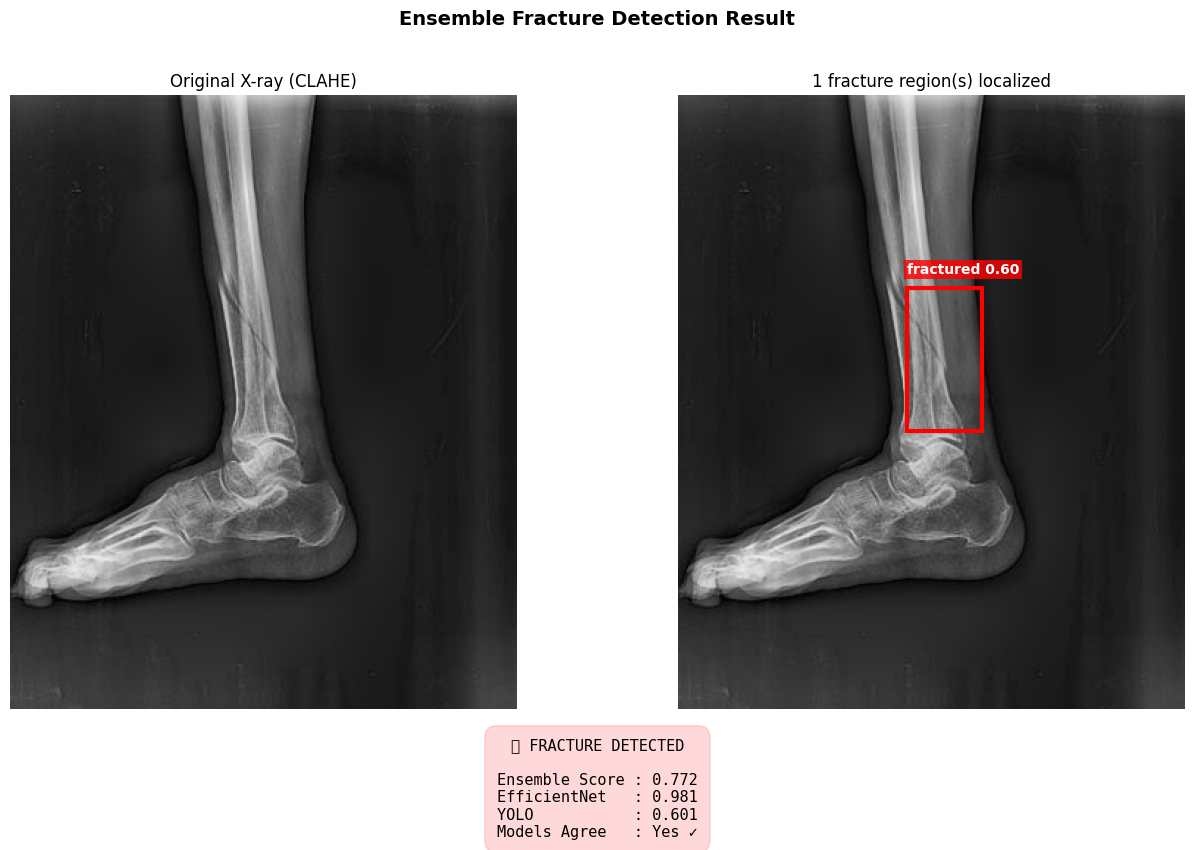

Saved → ensemble_result.png

── Result ──
  final_label         : Abnormal
  recommendation      : 🔴 FRACTURE DETECTED
  ensemble_score      : 0.7717
  effnet_score        : 0.9808
  yolo_score          : 0.6007
  models_agree        : True
  uncertain           : False
  num_regions         : 1


In [ ]:
# Test on a single image
test_dir = Path("/content/fracatlas_raw/Fracatlas/test/images")

test_imgs = list(test_dir.glob("*.jpg")) + list(test_dir.glob("*.png"))

print(f"Found {len(test_imgs)} images")

if test_imgs:
    sample = str(random.choice(test_imgs))
    print(f"\nRunning ensemble on: {sample}")
    result = visualize_ensemble(sample, save_path="ensemble_result.png")

    print("\n── Result ──")
    for k, v in result.items():
        if k != "detections":
            print(f"  {k:20s}: {v}")


Running batch test...
✅ batch_ensemble_test STARTED
/content/fracatlas_raw/Fracatlas/test/images/IMG0003625.jpg (640, 640) 0 249
/content/fracatlas_raw/Fracatlas/test/images/IMG0003420.jpg (640, 640) 0 255
/content/fracatlas_raw/Fracatlas/test/images/IMG0003565.jpg (640, 640) 2 230
/content/fracatlas_raw/Fracatlas/test/images/IMG0003308.jpg (640, 640) 0 217
/content/fracatlas_raw/Fracatlas/test/images/IMG0003524.jpg (640, 640) 0 222
/content/fracatlas_raw/Fracatlas/test/images/IMG0003373.jpg (640, 640) 4 241


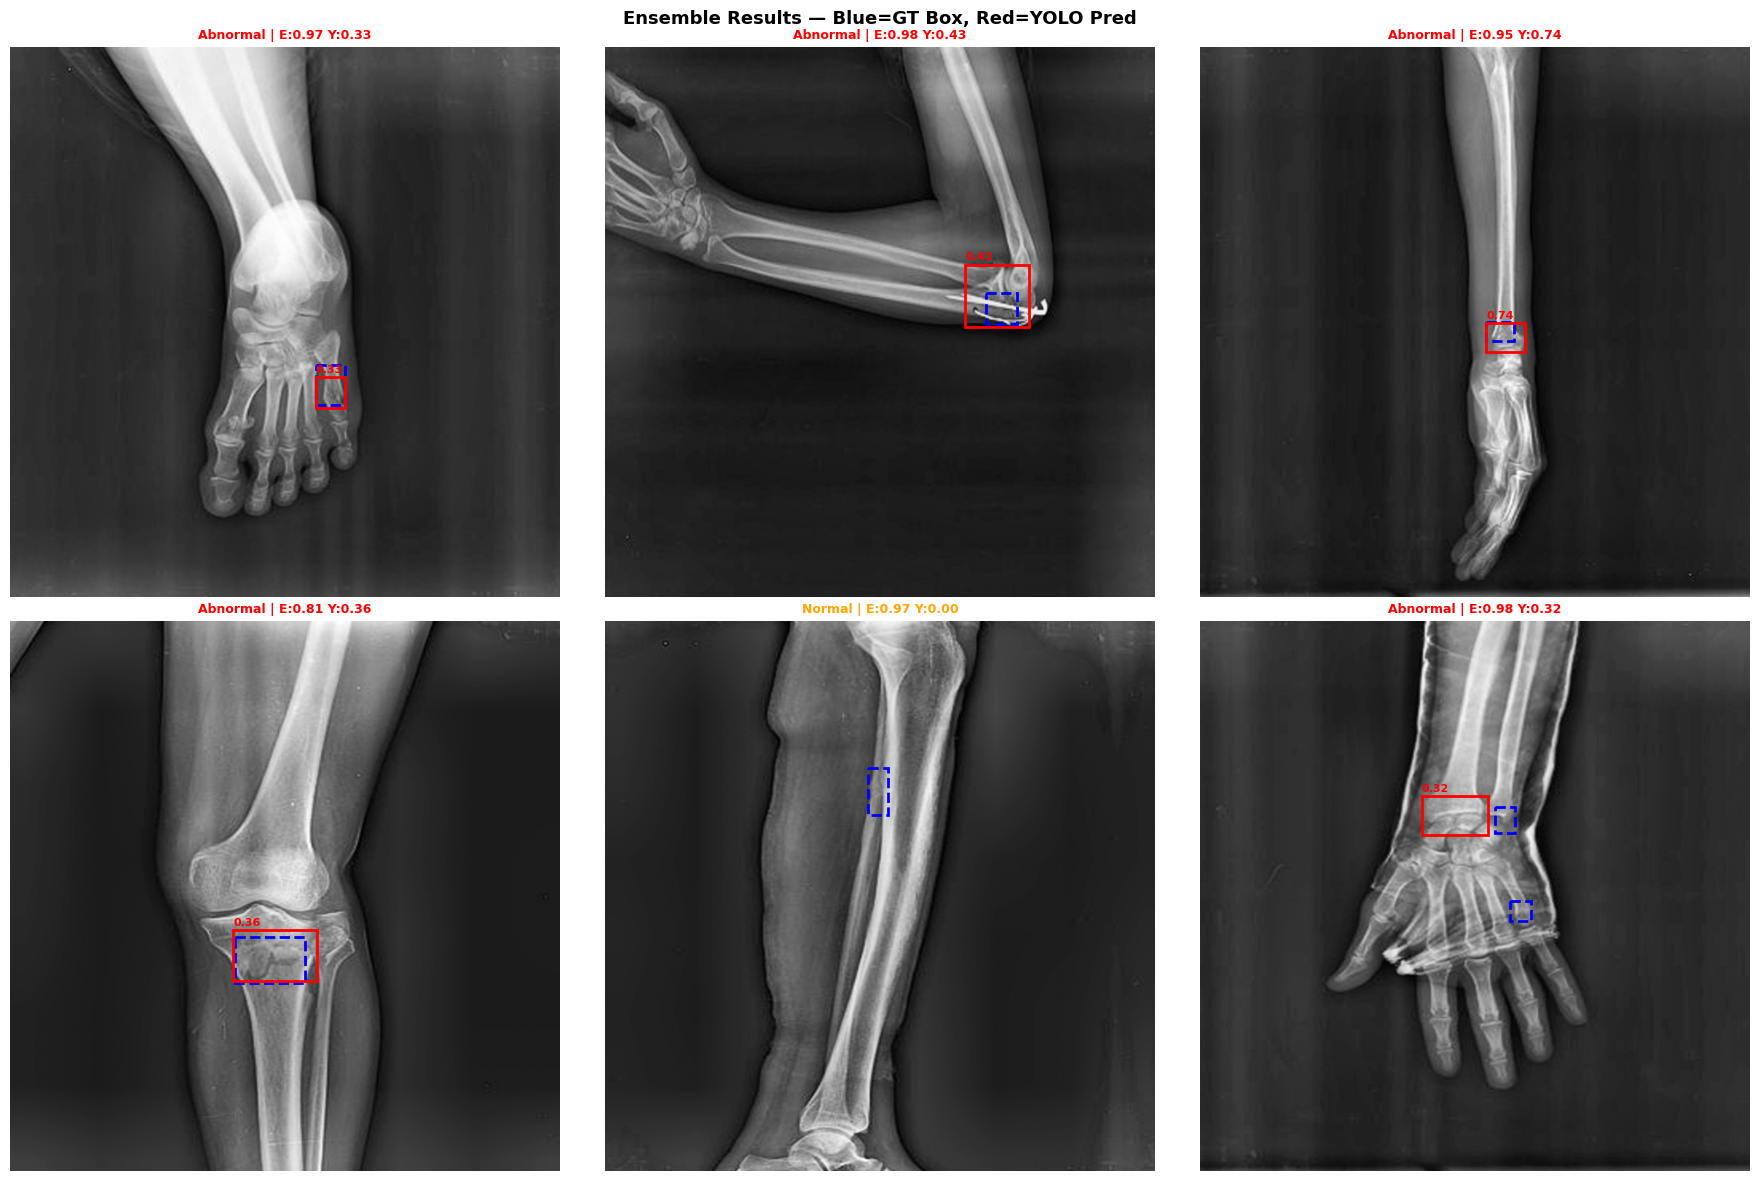

Saved → ensemble_batch.png


In [ ]:
    # Batch test
    print("\nRunning batch test...")
    batch_ensemble_test(n=6, save_path="ensemble_batch.png")

In [ ]:
data_yaml = """
path: /content/fracatlas_raw/Fracatlas
train: train/images
val: validation/images
test: test/images

names:
  0: fracture
"""
with open("dataset_eval.yaml", "w") as f:
    f.write(data_yaml)

In [ ]:
import os
print(os.listdir("/content/fracatlas_raw/Fracatlas/test"))

['images', 'labels']


In [ ]:
from pathlib import Path

label_dir = Path("/content/fracatlas_raw/Fracatlas/validation/lables")

empty = 0
non_empty = 0

for f in label_dir.glob("*.txt"):
    if f.stat().st_size == 0:
        empty += 1
    else:
        non_empty += 1

print("Empty labels:", empty)
print("Non-empty labels:", non_empty)

Empty labels: 0
Non-empty labels: 82


In [ ]:
import os

os.rename(
    "/content/fracatlas_raw/Fracatlas/validation/lables",
    "/content/fracatlas_raw/Fracatlas/validation/labels"
)

In [ ]:
!kaggle datasets download -d cjinny/mura-v11
!unzip -q mura-v11.zip -d /content/mura_dataset

Dataset URL: https://www.kaggle.com/datasets/cjinny/mura-v11
License(s): unknown
100% 3.14G/3.14G [00:52<00:00, 64.8MB/s]

